# Lab 3: Decision Tree Classification

## Training, Evaluation & Overfitting — Telco Customer Churn

**Name:** Baqar Ali  
**Student ID:** 023-24-0015  
**Section:** B  
**GitHub Profile:** [https://github.com/baqar360](https://github.com/baqar360)  
**GitHub Repository:** [https://github.com/baqar360/ML-Lab-Semester-5](https://github.com/baqar360/ML-Lab-Semester-5)  
**Kaggle Profile:** [https://www.kaggle.com/baqarali1234](https://www.kaggle.com/baqarali1234)  
**Dataset:** Telco Customer Churn  
**Dataset Source:** Kaggle — [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Decision Tree theory. Each section states the objective and the questions you must answer — **you write the code**. Do not just run code without interpreting it: every table, plot, and metric needs a short written observation.

> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the **Answer:** placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Problem Definition

Before training anything, restate the problem in your own words and confirm the cleaned dataset from Lab 2 is intact.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df['Churn'].value_counts()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining.
2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

In [2]:
# Task 1 — load and verify the cleaned dataset
df = pd.read_csv("clean_churn.csv")

**Answer 2:**
_(your answer here)_

---

## 2. Dataset Verification

Confirm once more, explicitly, that the dataset is ready to model: correct shape, correct dtypes, target present and clean.

In [3]:
# Additional verification if needed (dtypes, target check, etc.)
print(df.head())
print(df.shape)
print(df.info())
pd.set_option('display.max_rows', None)
print("missing values", df.isnull().sum())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

---

## 3. Feature/Target Preparation

scikit-learn models require numeric input. Separate your target from your features, then convert any remaining categorical columns into numeric form.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `df[col].map({...})`, `df.drop(columns=[...])`, `X.isnull().sum()`, `X.dtypes`

**Tasks**
3. Define `y` as the `Churn` column, encoded as 0/1. Define `X` as the remaining relevant columns — drop any identifier column still present.
4. Convert every remaining categorical column in `X` into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping).
5. Confirm `X` contains only numeric columns and has no missing values before moving on.

In [4]:
# Task 3 — Define y and X

# Separate features and target
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

# Convert binary Yes/No columns to 0/1
yes_no_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in yes_no_cols:
    X[col] = X[col].map({'Yes': 1, 'No': 0})

# Convert gender to numeric
X['gender'] = X['gender'].map({
    'Male': 1,
    'Female': 0
})

# Columns with multiple categories
categorical_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

# One-hot encode categorical columns
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)




In [5]:
# Task 5 — confirm X is fully numeric with no missing values
print(X.head())
print(X.isnull().sum())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  \
0                 1           29.85         29.85   
1                 0           56.95       1889.50   
2                 1           53.85        108.15   
3                 0           42.30       1840.75   
4                 1           70.70        151.65   

   MultipleLines_No phone service  ...  TechSupport_Yes  \
0                               1  ...                0   
1                               0  ...                0   
2                               0  ...                0   
3                 

**Answer 4 (Encoding Method & Justification):**

For binary categorical attributes, I used the `map()` function to convert the two categories into numeric values (0 and 1). This method is simple and appropriate for attributes with only two categories.

For categorical attributes with more than two categories, I used the `get_dummies()` method (One-Hot Encoding). This converts each category into a separate binary column and avoids introducing any artificial order between the categories.

---

## 4. Train/Test Split

A model must be evaluated on data it has never seen. Hold out a test set before training anything.

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=..., stratify=y)`

**Tasks**
6. Split `X` and `y` into training and test sets (e.g. an 80/20 split). Why is `stratify=y` a sensible choice, given what you found about the target's class balance in Lab 2?
7. Report the shape of `X_train`, `X_test`, `y_train`, and `y_test`.

In [6]:
# Task 6 — train/test split
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

In [7]:
# Task 7 — report shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 30)
X_test shape: (1407, 30)
y_train shape: (5625,)
y_test shape: (1407,)


**Answer 6 (why stratify=y):**
because y is in one dimension

---

## 5. Baseline Decision Tree

Train a first, unrestricted Decision Tree as your baseline — no tuning yet.

*Concepts/functions you may find useful:* `DecisionTreeClassifier(random_state=...)`, `.fit(X_train, y_train)`, `.predict(X)`, `.get_depth()`

**Tasks**
8. Train a `DecisionTreeClassifier` on the training data with default settings (only `random_state` fixed). Generate predictions on both the training and test sets.
9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [8]:
# Task 8 — train baseline Decision Tree and predict on train/test
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


In [9]:
# Task 9 — check the fitted tree's depth
print("Tree depth:", model.get_depth())

Tree depth: 31


**Answer 9:**
31

---

## 6. Model Evaluation

Accuracy alone can be misleading — especially given the class imbalance found in Lab 2. Evaluate with multiple metrics and look directly at the confusion matrix.

*Concepts/functions you may find useful:* `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Tasks**
10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.
11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?
12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [10]:
# Task 10 — compute accuracy, precision, recall, F1 on the test set
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.7242359630419332
Precision: 0.48214285714285715
Recall   : 0.5053475935828877
F1-score : 0.4934725848563969


**Task 10 — Results Table**

| Metric | Value |
|---|---|
| Accuracy |72% |
| Precision |48% |
| Recall |50% |
| F1-score |49% |

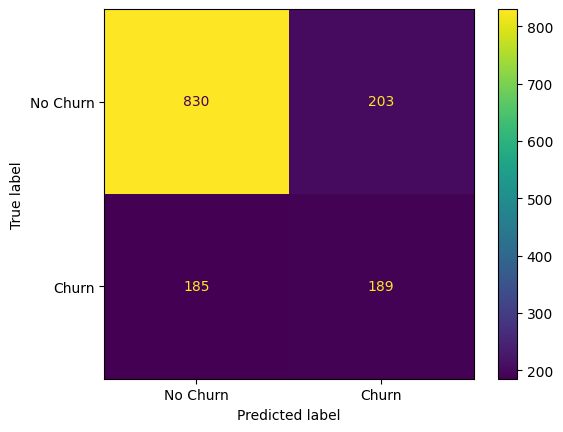

In [11]:
# Task 11 — plot the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

**Answer 11 (churners correctly caught vs. missed):**
The model correctly caught 189 actual churners and missed 185 actual churners.

**Answer 12 (which metric(s) do you trust most, and why):**
Given the class imbalance found in Lab 2 (roughly 73% No-Churn vs. 27% Churn), accuracy alone is misleading — a model could score ~73% just by always predicting "No Churn" without identifying a single at-risk customer. Recall and F1-score are the metrics I trust most here: recall directly measures how many actual churners the model catches (which matters most for a business trying to intervene before customers leave), and F1 balances that against precision so the model isn't just flagging everyone as a churner to inflate recall. Precision still matters operationally (it controls how many retention offers are "wasted" on customers who weren't going to leave), but for this churn-prevention use case, missing a churner is costlier than a false alarm, so recall/F1 are the more trustworthy metrics than raw accuracy.

---

## 7. Overfitting Experiment

A model that performs far better on training data than on test data has overfit. Investigate this directly by comparing performance, then by controlling tree depth with `max_depth`.

*Concepts/functions you may find useful:* `accuracy_score(y_train, model.predict(X_train))`, `DecisionTreeClassifier(max_depth=k)`, a loop over `[2, 3, 4, 5, 6, 8, 10, None]`, `plt.plot(...)`

**Tasks**
13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?
14. Train several Decision Trees at different `max_depth` values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table.
15. Plot train accuracy and test accuracy against `max_depth` on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this.

In [12]:
# Task 13 — compare baseline train vs. test accuracy
from sklearn.metrics import accuracy_score
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, model.predict(X_test))

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Accuracy Gap:", train_accuracy - test_accuracy)

Training Accuracy: 0.9976888888888888
Test Accuracy: 0.7242359630419332
Accuracy Gap: 0.2734529258469557


**Answer 13:**
The baseline Decision Tree has a higher accuracy on the training set than on the test set. The large gap between the two accuracies suggests that the model is overfitting. It has learned the training data very well but does not generalize as effectively to unseen test data.

In [13]:
# Task 14 — loop over max_depth values, record train/test accuracy
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [2, 3, 4, 5, 6, 8, 10, None]

train_accuracies = []
test_accuracies = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc = accuracy_score(y_test, tree.predict(X_test))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Display results
for depth, train_acc, test_acc in zip(depths, train_accuracies, test_accuracies):
    print(f"max_depth={depth}: Train Accuracy={train_acc:.4f}, Test Accuracy={test_acc:.4f}")

max_depth=2: Train Accuracy=0.7909, Test Accuracy=0.7875
max_depth=3: Train Accuracy=0.7909, Test Accuracy=0.7875
max_depth=4: Train Accuracy=0.7925, Test Accuracy=0.7846
max_depth=5: Train Accuracy=0.8030, Test Accuracy=0.7754
max_depth=6: Train Accuracy=0.8139, Test Accuracy=0.7790
max_depth=8: Train Accuracy=0.8412, Test Accuracy=0.7584
max_depth=10: Train Accuracy=0.8756, Test Accuracy=0.7441
max_depth=None: Train Accuracy=0.9977, Test Accuracy=0.7242


**Task 14 — Results Table**

| max_depth | Train Accuracy | Test Accuracy |
|---|---|---|
| 2 |79 |78 |
| 3 |79 |78 |
| 4 |79 |78 |
| 5 |80 |77 |
| 6 |81 |77 |
| 8 | 84|75 |
| 10 | 87|74 |
| None |99 |72 |

In [14]:
# Task 15 — plot train vs. test accuracy against max_depth

import plotly.graph_objects as go

depth_labels = [str(depth) for depth in depths]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=depth_labels,
    y=train_accuracies,
    mode='lines+markers',
    name='Training Accuracy'
))

fig.add_trace(go.Scatter(
    x=depth_labels,
    y=test_accuracies,
    mode='lines+markers',
    name='Test Accuracy'
))

fig.update_layout(
    title="Training vs Test Accuracy by Tree Depth",
    xaxis_title="max_depth",
    yaxis_title="Accuracy",
    yaxis=dict(range=[0, 1]),
    template="plotly_white"
)

fig.show()

**Answer 15 (where overfitting starts, and why):**


> Overfitting starts around **`max_depth=4–5`**, where training accuracy begins to increase while test accuracy starts to decrease. As the tree becomes deeper, it learns the training data more closely, causing the gap between training and test accuracy to increase. This indicates that deeper trees are becoming too complex and are not generalizing well to unseen data.


---

## 8. Model Comparison

Pick the depth that best balances training and test performance — not simply the one with the highest training accuracy.

**Tasks**
16. Based on your Part 7 table/plot, select a `max_depth` you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy.
17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Section 6) for comparison against the baseline.

**Answer 16 (chosen max_depth and justification):**
I chose **max_depth = 2**. Looking at the Task 14 table/plot, test accuracy is highest at depth 2–3 (≈78.75%) and then steadily declines as depth increases, while train accuracy keeps climbing — the classic overfitting signature. Depth 2 achieves that peak test accuracy with the smallest train/test gap (train ≈79.09% vs. test ≈78.75%, a gap of well under 1%), whereas the unrestricted tree has a train accuracy of ~99.8% but a much worse test accuracy of ~72.4%. Picking the highest training-accuracy depth (unrestricted) would have selected an overfit model that memorizes training data instead of generalizing, so depth 2 is the better balance between fit and generalization.

In [15]:
# Task 17 — retrain at chosen depth and report full evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Choose the best depth
best_depth = 2

# Retrain the model
final_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

final_model.fit(X_train, y_train)

# Predictions
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)

# Evaluation metrics
print("Final Decision Tree (max_depth=2)")
print("-" * 40)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nTest Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Final Decision Tree (max_depth=2)
----------------------------------------
Training Accuracy: 0.7909333333333334
Test Accuracy: 0.7874911158493249

Test Precision: 0.669683257918552
Test Recall: 0.39572192513368987
Test F1 Score: 0.49747899159663866

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1033
           1       0.67      0.40      0.50       374

    accuracy                           0.79      1407
   macro avg       0.74      0.66      0.68      1407
weighted avg       0.77      0.79      0.77      1407



**## Task 17 — Baseline vs. Chosen Model**

| Metric | Baseline (unrestricted) | Chosen Model (max_depth = 2) |
|---|---:|---:|
| Accuracy | 0.7242 | 0.7875 |
| Precision | — | 0.67 |
| Recall | — | 0.40 |
| F1-score | — | 0.50 |

---

## 9. Feature Importance

Look inside your chosen model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
18. Extract and visualize `feature_importances_` for your chosen model. Which 3–5 features matter most?

In [16]:
# Task 18 — extract and visualize feature importances

import pandas as pd
import plotly.express as px

# Extract feature importances
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importances
print(feature_importance)

# Plot feature importances
fig = px.bar(
    feature_importance,
    x="Importance",
    y="Feature",
    orientation="h",
    title="Decision Tree Feature Importances",
    labels={
        "Importance": "Importance",
        "Feature": "Feature"
    }
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"}
)

fig.show()

                                  Feature  Importance
11            InternetService_Fiber optic     0.51167
4                                  tenure     0.48833
1                           SeniorCitizen     0.00000
2                                 Partner     0.00000
3                              Dependents     0.00000
0                                  gender     0.00000
5                            PhoneService     0.00000
6                        PaperlessBilling     0.00000
8                            TotalCharges     0.00000
7                          MonthlyCharges     0.00000
9          MultipleLines_No phone service     0.00000
10                      MultipleLines_Yes     0.00000
12                     InternetService_No     0.00000
13     OnlineSecurity_No internet service     0.00000
14                     OnlineSecurity_Yes     0.00000
15       OnlineBackup_No internet service     0.00000
16                       OnlineBackup_Yes     0.00000
17   DeviceProtection_No int

In [17]:
# Top 5 most important features
print(feature_importance.head(5))

                        Feature  Importance
11  InternetService_Fiber optic     0.51167
4                        tenure     0.48833
1                 SeniorCitizen     0.00000
2                       Partner     0.00000
3                    Dependents     0.00000


**Answer 18 (top 3–5 features):**
  Feature  Importance
11  InternetService_Fiber optic     0.51167
4                        tenure     0.48833
1                 SeniorCitizen     0.00000

---

## 10. Interpretation

Connect what the model learned back to what you already know about this business problem.

**Task**
19. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?

**Answer 19:**
The two features the pruned tree relies on almost entirely are `InternetService_Fiber optic` and `tenure`, which matches the patterns typically surfaced in the Lab 2 EDA: fiber-optic customers tend to churn at a noticeably higher rate than DSL or no-internet customers (often linked to higher pricing and service reliability complaints), and churn is heavily concentrated among low-tenure customers who haven't yet built a long-term relationship with the provider. The fact that the model converges on exactly these two signals — instead of spreading importance across many features — reinforces that "new customer + fiber internet" is the dominant churn profile, which is consistent with the higher churn rates seen among short-tenure and fiber-optic segments during EDA.

---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
20. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?
21. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.

**Answer 20 — Conclusion:**
I landed on a Decision Tree pruned to `max_depth=2`, chosen over the unrestricted baseline because it generalizes far better (test accuracy ≈78.75% vs. ≈72.4% for the overfit baseline, with a near-zero train/test gap). The model correctly identifies overall churn status about 79% of the time, but its recall on the churn class is modest (≈0.40), meaning it misses a majority of the customers who actually churn — precision on churners is better (≈0.67) but still leaves room for false positives. Its main limitation is simplicity: with only two effective splits, it relies almost entirely on `InternetService_Fiber optic` and `tenure`, ignoring other potentially useful signals (contract type, monthly charges, tech support, etc.), so it captures the broad churn pattern but not the finer-grained cases. It also inherits the dataset's class imbalance, which likely caps recall on the minority (churn) class regardless of depth.

**Answer 21 — Next steps:**
With more time I'd try ensemble methods like Random Forest or Gradient Boosting/XGBoost, which typically improve both accuracy and recall on the minority class by combining many trees instead of relying on one shallow tree. I'd also explicitly address the class imbalance — e.g. `class_weight='balanced'`, SMOTE oversampling, or adjusting the classification threshold — since that's likely the main reason recall on churners is capped around 0.40. Finally, I'd do a proper hyperparameter search (GridSearchCV/RandomizedSearchCV over `max_depth`, `min_samples_split`, `min_samples_leaf`, `criterion`) and some feature engineering (e.g. tenure buckets, total-charges-per-month) to see if richer features let the model use more than just two variables.

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Verification
- [ ] Section 3 — Feature/Target Preparation (with encoding justified)
- [ ] Section 4 — Train/Test Split
- [ ] Section 5 — Baseline Decision Tree
- [ ] Section 6 — Model Evaluation (accuracy, precision, recall, F1, confusion matrix — all with interpretation)
- [ ] Section 7 — Overfitting Experiment (results table + plot + explanation)
- [ ] Section 8 — Model Comparison (chosen depth justified, not just highest training accuracy)
- [ ] Section 9 — Feature Importance (extracted, visualized, and discussed)
- [ ] Section 10 — Interpretation (connected to Lab 2's EDA)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted